In [4]:
import pandas as pd

df = pd.read_csv('spend_analysis_dataset.csv')
print(df.head())
print(df.columns.tolist())

  TransactionID                 ItemName         Category  Quantity  \
0        TXN001               Desk Chair        Furniture        10   
1        TXN002                  Stapler  Office Supplies        16   
2        TXN003  Annual Software License         Software         1   
3        TXN004                  Notepad       Stationery        13   
4        TXN005                  Notepad       Stationery        19   

   UnitPrice  TotalCost PurchaseDate         Supplier            Buyer  
0     113.15    1131.50   2024-04-19    TechMart Inc.     Kelly Joseph  
1      12.62     201.92   2024-07-06  CloudSoft Corp.     Kelly Joseph  
2    5649.34    5649.34   2024-09-10    TechMart Inc.     Kelly Joseph  
3       2.92      37.96   2024-01-21  FurniWorks Ltd.     Luis Holland  
4       1.39      26.41   2024-02-03    TechMart Inc.  Cynthia Jenkins  
['TransactionID', 'ItemName', 'Category', 'Quantity', 'UnitPrice', 'TotalCost', 'PurchaseDate', 'Supplier', 'Buyer']


In [5]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TransactionID  500 non-null    object 
 1   ItemName       500 non-null    object 
 2   Category       500 non-null    object 
 3   Quantity       500 non-null    int64  
 4   UnitPrice      500 non-null    float64
 5   TotalCost      500 non-null    float64
 6   PurchaseDate   500 non-null    object 
 7   Supplier       500 non-null    object 
 8   Buyer          500 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 35.3+ KB
None
TransactionID    0
ItemName         0
Category         0
Quantity         0
UnitPrice        0
TotalCost        0
PurchaseDate     0
Supplier         0
Buyer            0
dtype: int64


In [6]:
df = df.dropna()
df['Supplier'] = df['Supplier'].str.strip().str.upper()

# top suppliers by spend

In [7]:
spend_by_supplier = df.groupby('Supplier')['TotalCost'].sum().sort_values(ascending=False)
print(spend_by_supplier.head(10))

Supplier
TECHMART INC.         328761.73
QUICKDELIVER LTD.     285353.59
OFFICESUPPLIES CO.    223580.85
FURNIWORKS LTD.       202810.72
CLOUDSOFT CORP.       200073.64
Name: TotalCost, dtype: float64


# Top suppliers chart

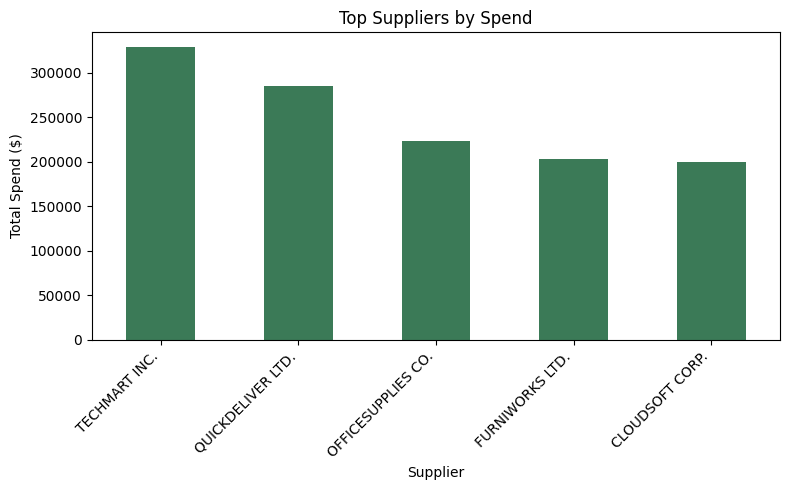

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
spend_by_supplier.plot(kind='bar', color='#3B7A57')
plt.title('Top Suppliers by Spend')
plt.ylabel('Total Spend ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart_top_suppliers.png', dpi=150)
plt.show()

# Supplier concentration

In [9]:
total_spend = spend_by_supplier.sum()
spend_by_supplier_pct = (spend_by_supplier / total_spend * 100).round(2)
print(spend_by_supplier_pct.head(10))

Supplier
TECHMART INC.         26.50
QUICKDELIVER LTD.     23.00
OFFICESUPPLIES CO.    18.02
FURNIWORKS LTD.       16.35
CLOUDSOFT CORP.       16.13
Name: TotalCost, dtype: float64


# Spend by category

In [10]:
spend_by_category = df.groupby('Category')['TotalCost'].sum().sort_values(ascending=False)
print(spend_by_category)

Category
Electronics        697805.23
Software           336018.00
Furniture          172818.61
Accessories         20857.24
Stationery           6753.18
Office Supplies      6328.27
Name: TotalCost, dtype: float64


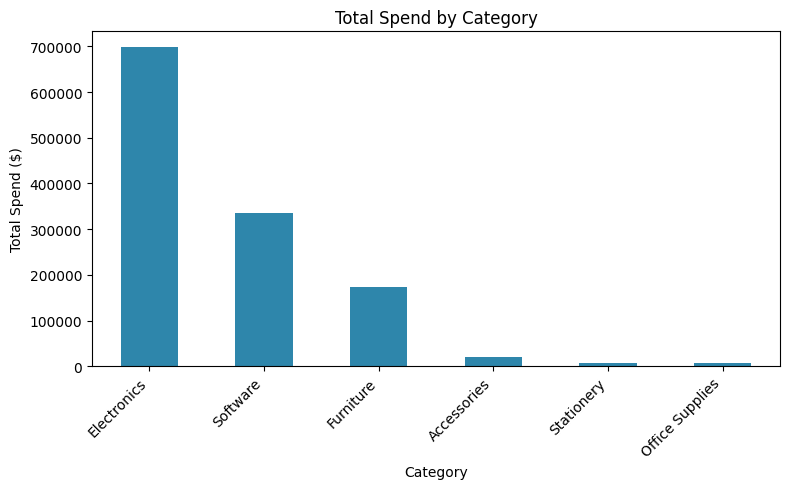

In [15]:
plt.figure(figsize=(8,5))
spend_by_category.plot(kind='bar', color='#2E86AB')
plt.title('Total Spend by Category')
plt.ylabel('Total Spend ($)')
plt.xlabel('Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart_spend_by_category.png', dpi=150)
plt.show()

# Spend by buyer

In [11]:
spend_by_buyer = df.groupby('Buyer')['TotalCost'].sum().sort_values(ascending=False)
print(spend_by_buyer)

Buyer
Walter Pena          96418.18
Jasmine Mcgee        94185.73
Dawn Padilla         76908.12
Kelly Joseph         76434.12
Aaron Hopkins        75865.04
Laura White          75235.84
Kayla Hanson         69848.40
Todd James           69219.24
Barry Johnson        68937.27
Melissa Mckee        66169.71
Stephanie Bennett    61853.79
Luis Holland         61082.03
Lisa Parks           58809.01
Cynthia Jenkins      52345.08
Amy Warner           51743.36
Rebecca Bell         51377.32
Jessica Hodges       50654.67
Noah Long            47999.46
Nicole Clay          22017.38
Kevin Adams          13476.78
Name: TotalCost, dtype: float64


# Price variance check

In [12]:
price_variance = df.groupby('ItemName')['UnitPrice'].agg(['min', 'max', 'mean', 'std'])
price_variance = price_variance[price_variance['std'] > 0].sort_values('std', ascending=False)
print(price_variance.head(10))

                             min      max         mean          std
ItemName                                                           
Annual Software License  5047.01  9909.24  7304.739130  1680.207361
Laptop                    806.52   994.88   894.131429    55.532022
Monitor                   201.29   381.95   283.736444    46.493444
Printer                   150.83   292.98   222.489333    43.673029
Whiteboard                100.82   199.35   149.204694    29.415129
Desk Chair                100.90   199.59   146.987736    28.083445
Laptop Bag                 20.30    46.27    32.130893     8.305573
Printer Ink                10.21    19.92    15.254286     3.023199
Stapler                     5.35    14.43    10.275833     2.745430
Notepad                     1.06     2.98     1.981042     0.574101


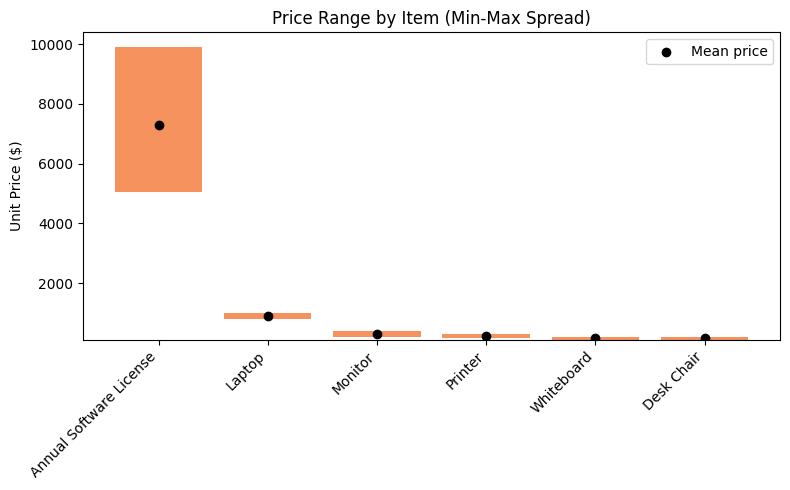

In [14]:
top_items = price_variance.head(6)

plt.figure(figsize=(8,5))
x = range(len(top_items))
plt.bar(x, top_items['max'] - top_items['min'], bottom=top_items['min'], color='#F26419', alpha=0.7)
plt.scatter(x, top_items['mean'], color='black', zorder=5, label='Mean price')
plt.xticks(x, top_items.index, rotation=45, ha='right')
plt.ylabel('Unit Price ($)')
plt.title('Price Range by Item (Min-Max Spread)')
plt.legend()
plt.tight_layout()
plt.savefig('chart_price_variance.png', dpi=150)
plt.show()

# Output